# Assignment 2) Euler vs. Taubin Smoothing

### What is the main problem with simple Laplace smoothing via Euler iterations?

$v^{(t+1)} = f(L)v^{(t)} = (I+\lambda\cdot L)v^{(t)}$ with $f(\cdot)$ beeing an univariate polynomial of
degree $m$

Then $f(L)$ has the same eigenvectors as $L$ and eigenvalues are $f(k_j) = 1 + \lambda\cdot k_j$ with $k_j$ beeing the $j\text{th}$  eigenvalue of $L$

After $N$ Laplace-Euler steps, we get: $v^{(t+N)} = f(L)^Nv^{(t)} = \sum_{j=1}^{n}f(k_j)^N\hat{v}_ju_j$

$f(k_j)^N = (1 + \lambda \cdot k_j)^N$ and Laplace-Operator is negativ semidefinit we know its eigenvalues are negative and therefore: $|1 + \lambda \cdot k_j| < 1 \implies \lim_{N\to \infty}(1 + \lambda \cdot k_j)^N = 0 $

Therefore the Laplace-Operator results in contraction which is the main problem

### How does Taubin Smoothing solve this problem?

Taubin propose a combination of two smoothing steps and define $f(k)$ in a way that no contraction occurs:
$f(k) = (1 + \mu k)(1 + \lambda k), \quad \mu < 0, \lambda > 0, |\mu| > |\lambda|$
1. contract the surface $\to \lambda > 0$
2. expand the smoothed surface again $\to \mu < 0, |\mu|>|\lambda|$

The Taubin-Operator is the definied as: $v^{(t+1)} = (I+\mu\cdot L)(I+\lambda\cdot L)v^{(t)}$

# Assignment 3) Laplace Smoothing

## a) 

Let $f(t)$ be a reel valued functions. Its Fourier Transform is given as:

$F(\omega) = \int_{-\infty}^\infty f(t)e^{-i\omega t}dt$

Now let $H(\omega)$ be a low-pass filter, definied as:

$H(\omega) = 
\begin{cases}
1, & |\omega| \le PB\\
0,  & else
\end{cases}$ So we define a threshold $PB$ and all frequencies above we cut out.

We can then apply the Filter to the Fourier Transform of $f(t)$:

$\tilde{F}(\omega) = H(\omega)F(\omega)$

and then perform the inverse Fourier Transform to get the filtered $f(t)$:

$\tilde{f}(t) = \tilde{F}(\omega)^{-1}$

The effect of low-pass filter are that sharp details gets smoothed out e.g. corner etc. or reduces noise etc. but we also loose fine datails

## b)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(linewidth=200)  # oder noch größer

P = np.array([
    [0, 1],
    [2, 2],
    [1, 0],
    [-2, -2]
], dtype=float)

samples_per_edge = 5
points = []

for i in range(len(P)):
    a = P[i]
    b = P[(i + 1) % len(P)]
    
    edge_points = np.linspace(a, b, samples_per_edge, endpoint=True)
    points.append(edge_points)


points = np.vstack(points)
N = len(points)

print("Sampled 20 polygon points:")
print(points)


L = np.zeros((N, N))

for i in range(N):
    L[i, i] = -2
    L[i, (i - 1) % N] = 1
    L[i, (i + 1) % N] = 1
L /= 2

print("\n20x20 Laplace matrix:")
print(f"1/2 * (\n{L*2}\n)")


Sampled 20 polygon points:
[[ 0.    1.  ]
 [ 0.5   1.25]
 [ 1.    1.5 ]
 [ 1.5   1.75]
 [ 2.    2.  ]
 [ 2.    2.  ]
 [ 1.75  1.5 ]
 [ 1.5   1.  ]
 [ 1.25  0.5 ]
 [ 1.    0.  ]
 [ 1.    0.  ]
 [ 0.25 -0.5 ]
 [-0.5  -1.  ]
 [-1.25 -1.5 ]
 [-2.   -2.  ]
 [-2.   -2.  ]
 [-1.5  -1.25]
 [-1.   -0.5 ]
 [-0.5   0.25]
 [ 0.    1.  ]]

20x20 Laplace matrix:
1/2 * (
[[-2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]
 [ 1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -2.  1.  0.  0.  0.  0.  0.  0

## c)

In [2]:
eigvals, eigvecs = np.linalg.eigh(L)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]


x = points[:, 0]
y = points[:, 1]

x_hat = eigvecs.T @ x
y_hat = eigvecs.T @ y


print("Eigenvalues:")
print(eigvals)

Eigenvalues:
[-1.78676518e-16 -4.89434837e-02 -4.89434837e-02 -1.90983006e-01 -1.90983006e-01 -4.12214748e-01 -4.12214748e-01 -6.90983006e-01 -6.90983006e-01 -1.00000000e+00 -1.00000000e+00 -1.30901699e+00
 -1.30901699e+00 -1.58778525e+00 -1.58778525e+00 -1.80901699e+00 -1.80901699e+00 -1.95105652e+00 -1.95105652e+00 -2.00000000e+00]


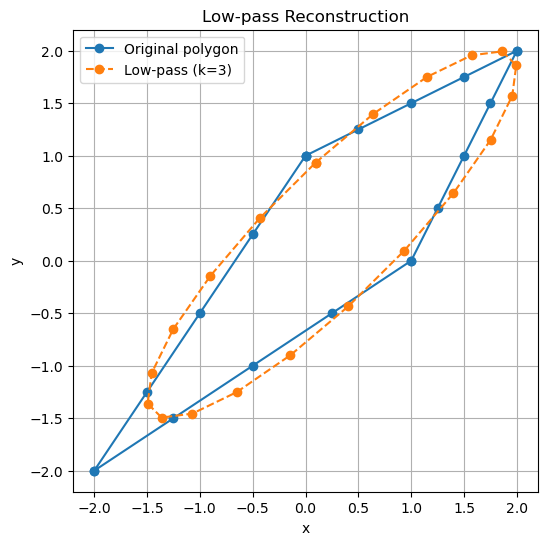

In [3]:
k = 3

x_hat_lp = np.zeros_like(x_hat)
y_hat_lp = np.zeros_like(y_hat)

x_hat_lp[:k] = x_hat[:k]
y_hat_lp[:k] = y_hat[:k]


x_lp = eigvecs @ x_hat_lp
y_lp = eigvecs @ y_hat_lp


x_closed = np.append(x, x[0])
y_closed = np.append(y, y[0])
x_lp_closed = np.append(x_lp, x_lp[0])
y_lp_closed = np.append(y_lp, y_lp[0])

plt.figure(figsize=(6, 6))
plt.plot(x_closed, y_closed, 'o-', label="Original polygon")
plt.plot(x_lp_closed, y_lp_closed, 'o--', label="Low-pass (k=3)")
plt.title("Low-pass Reconstruction")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Discussion: As one can see our low-pass filter smoothed out sharp corners. So in the end we got exactly what we expected from our theoretical thoughts from a).

## e)

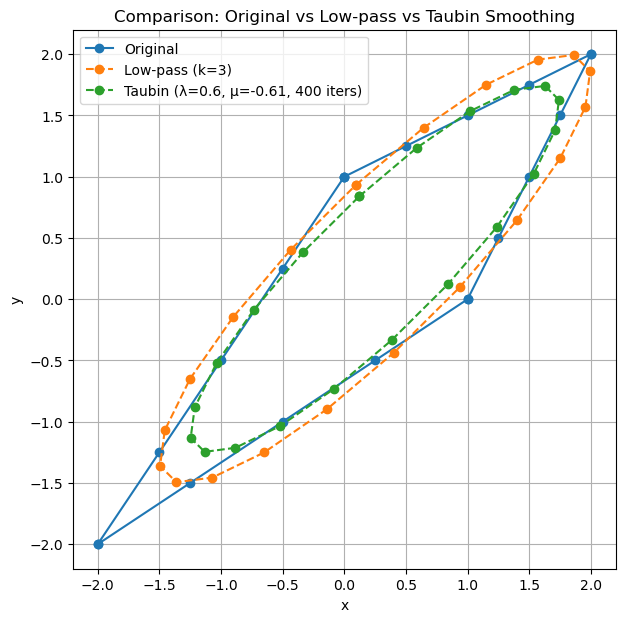

In [34]:
lambda_ = 0.6
mu = -0.61
iterations = 400

N = len(points)
X = points.copy()
I = np.eye(N)

# Taubin Operator:
T = (I + mu * L) @ (I + lambda_ * L)

for _ in range(iterations):
    X = T @ X
X_taubin = X


x_closed = np.append(x, x[0])
y_closed = np.append(y, y[0])
x_lp_closed = np.append(x_lp, x_lp[0])
y_lp_closed = np.append(y_lp, y_lp[0])
x_taubin_closed = np.append(X_taubin[:,0], X_taubin[0,0])
y_taubin_closed = np.append(X_taubin[:,1], X_taubin[0,1])

plt.figure(figsize=(7,7))
plt.plot(x_closed, y_closed, 'o-', label="Original")
plt.plot(x_lp_closed, y_lp_closed, 'o--', label="Low-pass (k=3)")
plt.plot(x_taubin_closed, y_taubin_closed, 'o--', label=f"Taubin (λ={lambda_}, μ={mu}, {iterations} iters)")
plt.title("Comparison: Original vs Low-pass vs Taubin Smoothing")
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Discussion: Taubin with manuel adjusted parameter $\lambda$ and $\mu$ does not leave the bounds of the original polygon. While the low-pass filter leaves the bounds of original polygon. Furthermore booth soomthing methods smoothed the polygon well.